In [233]:
import os
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import zipfile
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

In [234]:
zip_path = 'J_S_Image_Classifier/image.zip'
target_folder = 'J_S_Image_Classifier/extracted_images/'
# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_folder)
    image_folder = 'J_S_Image_Classifier/extracted_images/'
image_files = os.listdir(image_folder)
directory = 'J_S_Image_Classifier/extracted_images/image/'
image_files = [filename for filename in os.listdir(directory) if filename.endswith('.jpg') or filename.endswith('.png')]


In [235]:
# Function to classify the image based on color
image_path = directory + f"j{13}.jpg"
def classify_image(image_path):
    image = Image.open(image_path)
    image = image.convert("RGB")
    red, green, blue = np.mean(image.getdata(band=0)), np.mean(image.getdata(band=1)), np.mean(image.getdata(band=2))
    if (green > blue and green > red) or red > blue:
        return "Jungle"
        
    else:
        return "Sea"
    
    


In [236]:
# Lists to hold the true labels and predicted labels
true_labels = []
predicted_labels = []

In [237]:
# Iterate over the image dataset
true_labels = []
predicted_labels = []

number_of_jungle_pics = 42
for i in range(1, number_of_jungle_pics+1):
    image_path = directory + f"j{i}.jpg"
    true_labels.append("Jungle")
    predicted_labels.append(classify_image(image_path))
    if classify_image(image_path) == "Sea":
        print(i)

number_of_sea_pics = 40
for i in range(1, number_of_sea_pics+1):
    image_path = directory + f"s{i}.jpg"
    true_labels.append("Sea")
    predicted_labels.append(classify_image(image_path))
    if classify_image(image_path) == "Jungle":
        print(i)


41
42
24


Results considering Red color
__________________________________________
Confusion Matrix:
[[40  2]
 [ 1 39]]
Recall: 0.9523809523809523
Precision: 0.975609756097561


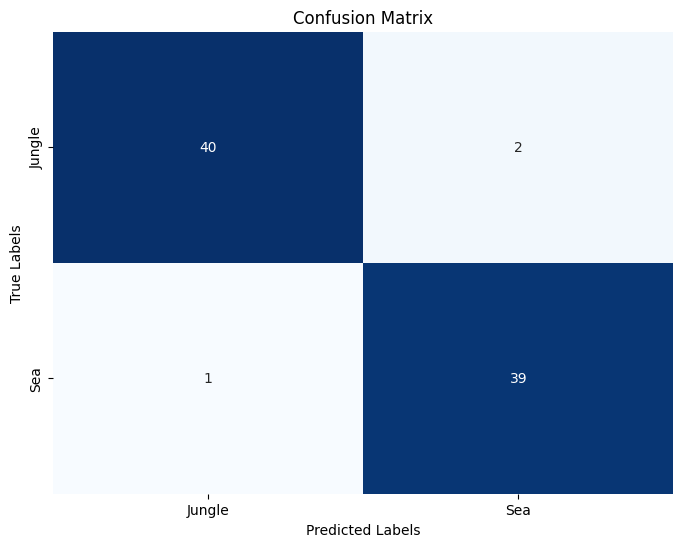

In [238]:
# Calculate confusion matrix, recall, and precision
confusion = confusion_matrix(true_labels, predicted_labels)
recall = confusion[0][0] / (confusion[0][0] + confusion[0][1])
precision = confusion[0][0] / (confusion[0][0] + confusion[1][0])

print("Results considering Red color")
print("__________________________________________")
print("Confusion Matrix:")
print(confusion)
print("Recall:", recall)
print("Precision:", precision)
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Jungle', 'Sea'], yticklabels=['Jungle', 'Sea'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()